In [36]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sn 
import plotly.express as px 
import plotly.graph_objects as go 
import warnings
warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv('stock_data.csv')
df.head()

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    object 
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), object(1)
memory usage: 17.2+ KB


In [39]:
df.shape

(365, 6)

In [40]:
df.describe()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
count,365.000000,365.000000,365.000000,365.000000,365.000000
mean,107.772577,81.105216,94.519502,117.407560,106.866865
std,7.398296,11.435212,6.519213,6.778527,3.760968
min,91.474442,62.414219,81.111434,99.909756,99.833309
25%,101.603117,69.328263,89.788068,112.209912,103.927072
50%,107.421299,84.283525,94.495546,117.788079,106.411328
75%,113.741728,91.548859,99.919465,123.132365,109.178007
max,121.901773,100.160928,107.588373,129.911386,116.243803


In [41]:
df.isnull().sum()

Unnamed: 0    0
Stock_1       0
Stock_2       0
Stock_3       0
Stock_4       0
Stock_5       0
dtype: int64

In [42]:
df.duplicated().count()

np.int64(365)

# EDA

In [43]:
# Type conversion 

# convert object to numeric int
df = df.apply(pd.to_numeric , errors ='ignore' )

# Convert float columns to int
float_cols = df.select_dtypes(include=[float]).columns
df[float_cols] = df[float_cols].astype(int)

print(df.dtypes)

Unnamed: 0    object
Stock_1        int64
Stock_2        int64
Stock_3        int64
Stock_4        int64
Stock_5        int64
dtype: object


<Axes: >

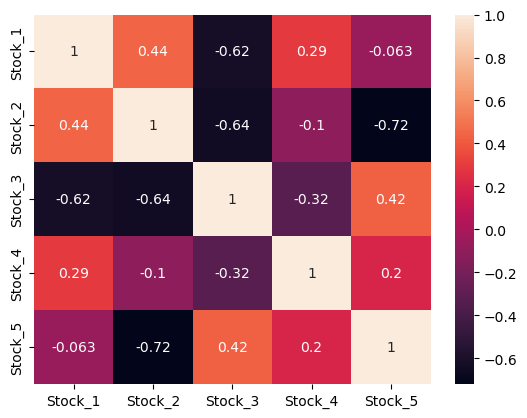

In [44]:
sn.heatmap(df.corr(numeric_only=True) , annot = True)

In [45]:
df.columns

Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='object')

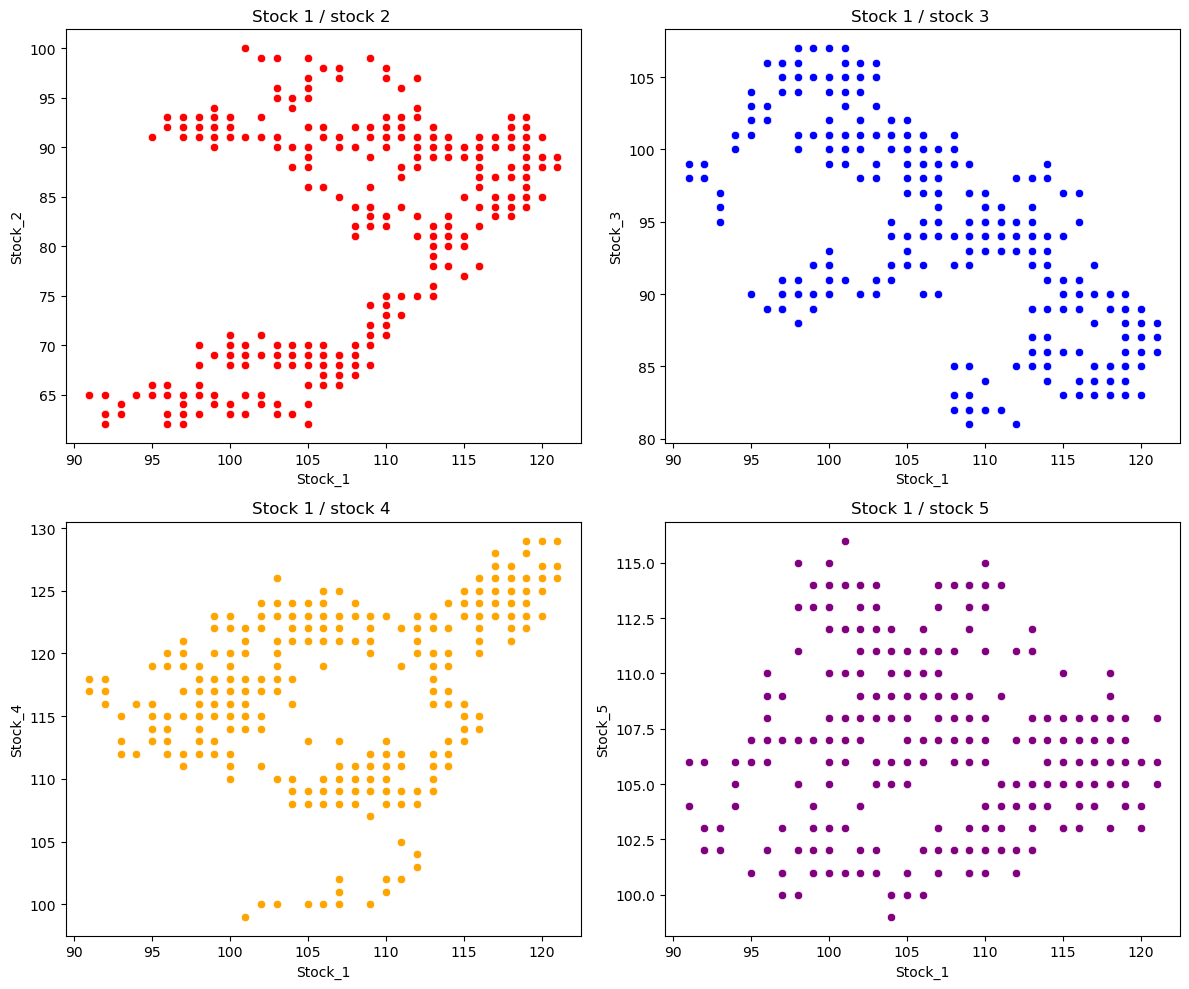

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sn.scatterplot( x= df['Stock_1'] , y = df['Stock_2'] , ax=axes[0,0], color = 'r')
axes[0,0].set_title('Stock 1 / stock 2 ')

sn.scatterplot( x= df['Stock_1'] , y = df['Stock_3'], ax=axes[0,1] , color = 'b' )
axes[0,1].set_title('Stock 1 / stock 3 ')

sn.scatterplot( x= df['Stock_1'] , y = df['Stock_4'], ax=axes[1,0] , color = 'orange')
axes[1,0].set_title('Stock 1 / stock 4 ')

sn.scatterplot( x= df['Stock_1'] , y = df['Stock_5'] , ax=axes[1,1], color = 'purple')
axes[1,1].set_title('Stock 1 / stock 5 ')

plt.tight_layout()
plt.show()

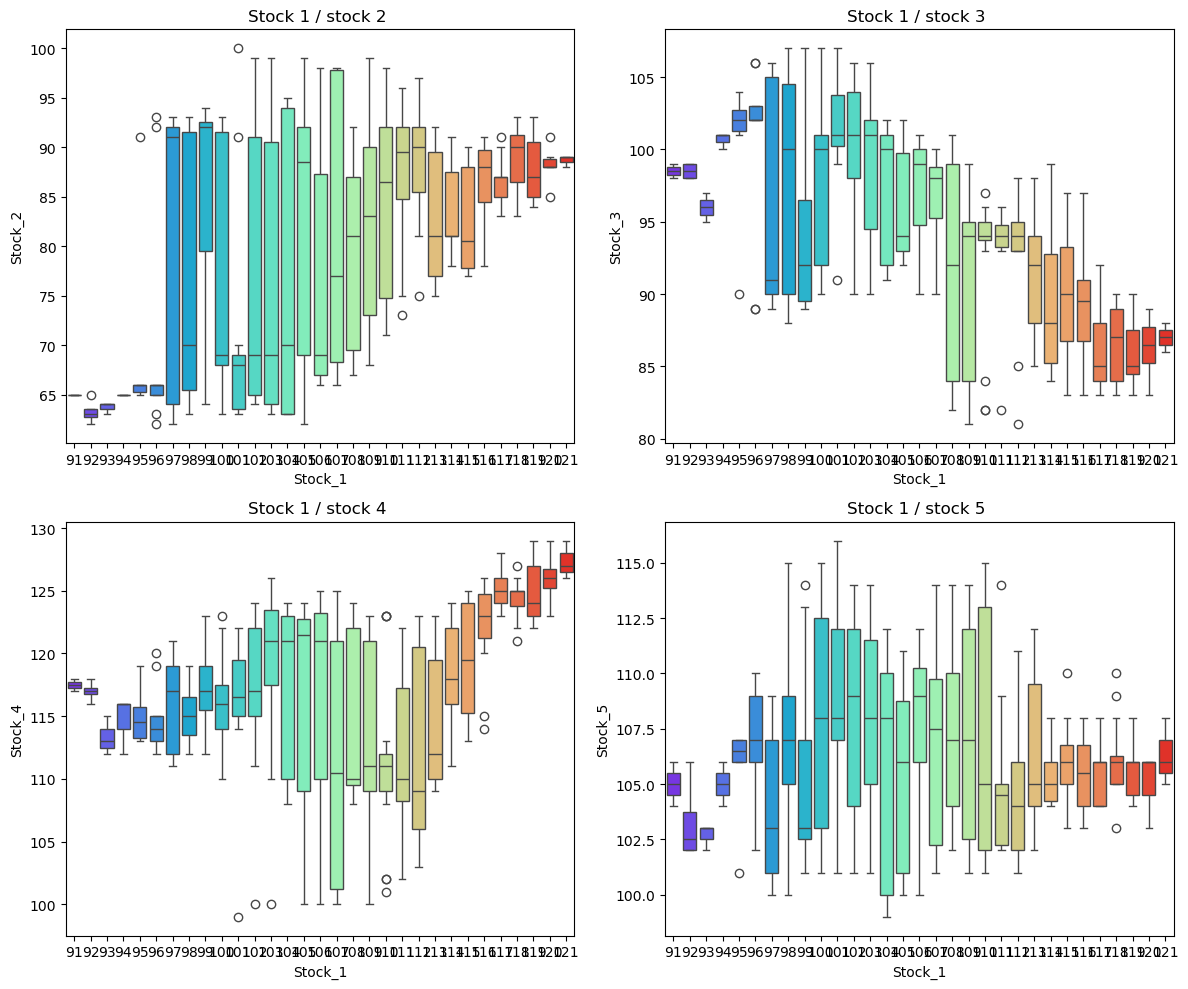

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sn.boxplot( x= df['Stock_1'] , y = df['Stock_2'] , ax=axes[0,0], palette='rainbow')
axes[0,0].set_title('Stock 1 / stock 2 ')

sn.boxplot( x= df['Stock_1'] , y = df['Stock_3'], ax=axes[0,1] , palette='rainbow')
axes[0,1].set_title('Stock 1 / stock 3 ')

sn.boxplot( x= df['Stock_1'] , y = df['Stock_4'], ax=axes[1,0] , palette='rainbow')
axes[1,0].set_title('Stock 1 / stock 4 ')

sn.boxplot( x= df['Stock_1'] , y = df['Stock_5'] , ax=axes[1,1], palette='rainbow')
axes[1,1].set_title('Stock 1 / stock 5 ')

plt.tight_layout()
plt.show()

In [48]:
#  Convert date column

df['Unnamed: 0'] = pd.to_datetime(df['Unnamed: 0'])
print(df['Unnamed: 0'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 365 entries, 0 to 364
Series name: Unnamed: 0
Non-Null Count  Dtype         
--------------  -----         
365 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.0 KB
None


In [49]:
# Create target column (next day Stock_1 price)

df['Target'] = df['Stock_1'].shift(-1)

# Remove last NaN row 
df.dropna(inplace=True)

In [50]:
df.columns

Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5',
       'Target'],
      dtype='object')

In [51]:
# Features 
X = df[['Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']]
y = df['Target']

In [52]:
# extract feature 

df['Year'] = df['Unnamed: 0'].dt.year
df['Months'] = df['Unnamed: 0'].dt.month
df['Day'] = df['Unnamed: 0'].dt.day

In [53]:
df.drop('Unnamed: 0', axis = 1 , inplace = True)

In [54]:
df.dropna(inplace=True)

# Feature Engineering 

In [55]:
# 1. Lag Features

df['Stock_1_Lag_1'] = df['Stock_1'].shift(1)
df['Stock_1_Lag_2'] = df['Stock_1'].shift(2)

print(df[['Stock_1_Lag_1', 'Stock_1_Lag_2'  ]].head())
print(df[['Stock_1_Lag_1', 'Stock_1_Lag_2' ]].dtypes)


   Stock_1_Lag_1  Stock_1_Lag_2
0            NaN            NaN
1          101.0            NaN
2          102.0          101.0
3          103.0          102.0
4          105.0          103.0
Stock_1_Lag_1    float64
Stock_1_Lag_2    float64
dtype: object


In [56]:
# Fill NaN values using backward fill 
df[['Stock_1_Lag_1' , 'Stock_1_Lag_2' ]] = df[['Stock_1_Lag_1' , 'Stock_1_Lag_2' ]].bfill()

# converting into int 
df[['Stock_1_Lag_1' , 'Stock_1_Lag_2' ]] = df[['Stock_1_Lag_1' , 'Stock_1_Lag_2']].astype(int)

print(df[['Stock_1_Lag_1', 'Stock_1_Lag_2', ]].head())
print(df[['Stock_1_Lag_1', 'Stock_1_Lag_2',]].dtypes)

   Stock_1_Lag_1  Stock_1_Lag_2
0            101            101
1            101            101
2            102            101
3            103            102
4            105            103
Stock_1_Lag_1    int64
Stock_1_Lag_2    int64
dtype: object


In [57]:
# 2. Moving Average

df['MA_5'] = df['Stock_1'].rolling(window=5).mean()
df['MA_10'] = df['Stock_1'].rolling(window=10).mean()

# converting into int 
df[['MA_5' , 'MA_10']] = df[['MA_5' , "MA_10"]].bfill()

df[['MA_5' , 'MA_10']] = df[['MA_5' , "MA_10"]].astype(int)
print(df[['MA_5', 'MA_10']].head())
print(df[['MA_5', 'MA_10']].dtypes)

   MA_5  MA_10
0   103    105
1   103    105
2   103    105
3   103    105
4   103    105
MA_5     int64
MA_10    int64
dtype: object


In [58]:
# 3. Rolling Standard Deviation (Volatility)

df['Volatility_5'] = df['Stock_1'].rolling(window=5).std()

In [59]:
# 4. Daily Return

# Pct_change -> Calculate how much Stock_1 changed compared to the previous day.
df['Daily_Return'] =df['Stock_1'].pct_change()

In [60]:
# 5. Price Difference 
df['Price_diff'] = df['Stock_1'].diff()

In [61]:
# Now Feature Engineeing for all feature 

In [62]:
# 1. Lag Features

df['Stock_2_Lag_1'] = df['Stock_2'].shift(1)
df['Stock_2_Lag_2'] = df['Stock_2'].shift(2)

# Fill NaN values using backward fill 
df[['Stock_2_Lag_1' , 'Stock_2_Lag_2' ]] = df[['Stock_2_Lag_1' , 'Stock_2_Lag_2' ]].bfill()

# converting into int 
df[['Stock_2_Lag_1' , 'Stock_2_Lag_2' ]] = df[['Stock_2_Lag_1' , 'Stock_2_Lag_2']].astype(int)

print(df[['Stock_2_Lag_1', 'Stock_2_Lag_2', ]].head())
print(df[['Stock_2_Lag_1', 'Stock_2_Lag_2',]].dtypes)

   Stock_2_Lag_1  Stock_2_Lag_2
0            100            100
1            100            100
2             99            100
3             99             99
4             99             99
Stock_2_Lag_1    int64
Stock_2_Lag_2    int64
dtype: object


In [63]:
#  Moving Average

df['Stock_2_MA_5'] = df['Stock_2'].rolling(window=5).mean()

# Fill NaN
df['Stock_2_MA_5'] = df['Stock_2_MA_5'].bfill()

# Convert to int
df['Stock_2_MA_5'] = df['Stock_2_MA_5'].astype(int)

print(df['Stock_2_MA_5'].head())
print(df['Stock_2_MA_5'].dtypes)

0    99
1    99
2    99
3    99
4    99
Name: Stock_2_MA_5, dtype: int64
int64


In [64]:
# Volatility for Stock_2
df['Stock_2_Volatility'] = df['Stock_2'].rolling(window=5).std()

# Fill NaN
df['Stock_2_Volatility'] = df['Stock_2_Volatility'].bfill()

# Convert to int
df['Stock_2_Volatility'] = df['Stock_2_Volatility'].astype(int)

print(df['Stock_2_Volatility'].head())
print(df['Stock_2_Volatility'].dtypes)

0    0
1    0
2    0
3    0
4    0
Name: Stock_2_Volatility, dtype: int64
int64


In [65]:
# Daily Return for Stock_2 

df['Stock_2_Return'] = df['Stock_2'].pct_change()

# Fill NaN
df['Stock_2_Return'] = df['Stock_2_Return'].bfill()

# Convert percentage float -> int
df['Stock_2_Return'] = (df['Stock_2_Return'] * 100).astype(int)

print(df['Stock_2_Return'].head())
print(df['Stock_2_Return'].dtypes)

0   -1
1   -1
2    0
3    0
4   -1
Name: Stock_2_Return, dtype: int64
int64


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364 entries, 0 to 363
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Stock_1             364 non-null    int64  
 1   Stock_2             364 non-null    int64  
 2   Stock_3             364 non-null    int64  
 3   Stock_4             364 non-null    int64  
 4   Stock_5             364 non-null    int64  
 5   Target              364 non-null    float64
 6   Year                364 non-null    int32  
 7   Months              364 non-null    int32  
 8   Day                 364 non-null    int32  
 9   Stock_1_Lag_1       364 non-null    int64  
 10  Stock_1_Lag_2       364 non-null    int64  
 11  MA_5                364 non-null    int64  
 12  MA_10               364 non-null    int64  
 13  Volatility_5        360 non-null    float64
 14  Daily_Return        363 non-null    float64
 15  Price_diff          363 non-null    float64
 16  Stock_2_Lag_1

In [67]:
float_col = df.select_dtypes(include=[float])

for col in float_col: 
    df[col] = df[col].bfill().astype(int)

In [69]:
df.drop(columns=['Year','Lag_3','MA_10','Price_diff','Stock_1_Lag_1','Stock_1_Lag_2','Stock_2_Lag_2'], inplace=True)
print("\nShape :", df.shape)
print("\nDataset Info:\n")
print(df.info())

KeyError: "['Lag_3'] not found in axis"

# NOW SPLIT THE X & y

In [70]:
X = df.drop(columns=['Target'], axis = 1)
y = df['Target']
y.head()

0    102
1    103
2    105
3    107
4    106
Name: Target, dtype: int64

In [71]:
# Train Test Split 

from sklearn.model_selection import train_test_split

In [72]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,shuffle=False,  random_state=42)

In [73]:
# Standard Scaling 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [74]:
print("X Train Shape :", X_train_scaled.shape)
print("X Test Shape  :", X_test_scaled.shape)

# Preview Scaled Data
print("\nScaled Training Data:\n")
print(X_train_scaled[:5])

X Train Shape : (291, 20)
X Test Shape  : (73, 20)

Scaled Training Data:

[[-1.24016792  1.68456407  1.28377222 -2.44121357 -1.29577636  0.
  -1.55539999 -1.63638472 -1.23666411 -1.23221035 -0.88552654 -0.59407037
   2.43450596  0.          0.86540837  1.67262563  1.66090856  1.60460988
  -0.5902759  -0.94944907]
 [-1.08923154  1.57484873  1.10073561 -2.30251908 -1.02253656  0.
  -1.55539999 -1.52224571 -1.23666411 -1.23221035 -0.88552654 -0.59407037
   2.43450596  0.          0.86540837  1.67262563  1.66090856  1.60460988
  -0.5902759  -0.94944907]
 [-0.93829517  1.57484873  1.10073561 -2.30251908 -1.29577636  0.
  -1.55539999 -1.4081067  -1.08596509 -1.23221035 -0.88552654 -0.59407037
   2.43450596  0.          0.86540837  1.56295144  1.66090856  1.60460988
  -0.5902759   0.11320354]
 [-0.63642243  1.57484873  0.917699   -2.30251908 -1.29577636  0.
  -1.55539999 -1.29396769 -0.93526607 -1.08180212 -0.88552654 -0.59407037
   2.43450596  0.          1.74287818  1.56295144  1.55126147 

In [75]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

models = { 
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'SVR': SVR(), 
    'XGBoost': XGBRegressor()
}

In [77]:
results = []

In [78]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred) # metrices
    mse = mean_squared_error(y_test , y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae, 2),
        'MSE': round(mse, 4), 
        'RMSE':round(rmse,4),
        'R2 Score': round(r2, 4)
    })    

In [79]:
results_df = pd.DataFrame(results)

In [80]:
# Sort by R2 Score 
results_df = results_df.sort_values(by = 'R2 Score', ascending=False)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.89,1.2836,1.1330,0.9436
1,Random Forest,2.00,7.3280,2.7070,0.6778
3,XGBoost,2.49,9.3489,3.0576,0.5889
2,SVR,4.44,32.6193,5.7113,-0.4344


In [81]:
import joblib

joblib.dump(models['Linear Regression'] , 'Linear Regression_StockPrice_Prediction.pkl')
joblib.dump(scaler , 'scaler.pkl')
joblib.dump(X.columns.to_list(), 'columns.pkl')

['columns.pkl']